In [31]:
from uszipcode import SearchEngine
import pandas as pd
import seaborn as sns
from scipy import stats
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import warnings
from scipy.stats import mstats, pearsonr
import sqlite3

warnings.filterwarnings('ignore')

In [7]:
avg_miles_by_state = pd.read_excel('Data/Avg_Miles_data_dictionary.xlsx')

avg_miles_by_state.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51 entries, 0 to 50
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   STATE             51 non-null     object
 1   State Abbv        51 non-null     object
 2   Miles Per Driver  51 non-null     int64 
dtypes: int64(1), object(2)
memory usage: 1.3+ KB


In [4]:
vehicles = pd.read_csv('Data/mega_df.csv')
vehicles.columns

In [5]:
vehicles.isna().sum()

Unnamed: 0.1                0
Unnamed: 0                  0
Price                       0
City                        0
VIN                         1
Date                  1532661
Manufacturing Year          0
Manufacturer             1970
Model Name                461
cylinders               75152
drive                   67923
transmission            26257
odometer                 1306
Post Content            28095
State                    1288
dtype: int64

In [12]:
print("NUmber of unique values in State column:", vehicles.State.nunique())
vehicles.State.unique()

NUmber of unique values in State column: 52


array(['OH', 'FL', 'OR', 'IL', 'TX', 'CA', 'NY', 'WI', 'NV', 'MA', 'MN',
       'HI', 'CO', 'AZ', 'IA', 'OK', 'PA', 'MO', 'NJ', 'GA', 'KS', 'NH',
       'VA', 'KY', 'TN', 'MD', 'NC', 'ID', 'CT', 'MS', 'UT', 'LA', 'IN',
       'ME', 'NM', 'SC', 'AL', 'RI', 'VT', 'NE', 'WA', 'AR', 'DE', 'MI',
       'MT', 'WY', 'WV', 'SD', 'DC', 'ND', nan, 'AK', 'PR'], dtype=object)

In [13]:
vehicles['Manufacturing Year'].unique()

array([2019, 2017, 2012, 2003, 2007, 2000, 2009, 2013, 2011, 2010, 2016,
       2005, 2020, 2002, 2018, 2006, 2001, 2014, 2004, 2008, 2015, 2021,
       2022], dtype=int64)

In [14]:
print('Number of rows in dataset with car listings from 2000 Models: ', vehicles[vehicles['Manufacturing Year'] >= 2000].shape[0])
print('Number of rows in dataset with car listings from 2005 Models: ', vehicles[vehicles['Manufacturing Year'] >= 2005].shape[0])
print('Number of rows in dataset with car listings from 2010 Models: ', vehicles[vehicles['Manufacturing Year'] >= 2010].shape[0])

Number of rows in dataset with car listings from 2000 Models:  1633954
Number of rows in dataset with car listings from 2005 Models:  1599961
Number of rows in dataset with car listings from 2010 Models:  1484842


In [15]:
print('Number of rows in dataset with car listings from 2010 Models: ', vehicles[(vehicles['Manufacturing Year'] >= 2000) & (vehicles['Price'] != 0)].shape[0])

Number of rows in dataset with car listings from 2010 Models:  1633954


In [16]:
vehicles['Manufacturer'].unique()

array(['Chevrolet', nan, 'Honda', 'Plymouth', 'Toyota', 'Aston Martin',
       'Nissan', 'Volvo', 'Ford', 'Dodge', 'Chrysler', 'Subaru',
       'Hyundai', 'Mercedes-Benz', 'Mazda', 'HUMMER', 'AM General', 'RAM',
       'JEEP', 'Acura', 'SRT', 'GMC', 'MINI', 'harley-davidson', 'Buick',
       'Pontiac', 'Oldsmobile', 'Cadillac', 'Audi', 'Saturn', 'Isuzu',
       'Lincoln', 'Mercury', 'Volkswagen', 'Saleen', 'Mitsubishi',
       'Suzuki', 'Lexus', 'FIAT', 'Saab', 'Kia', 'BMW', 'Scion',
       'Infiniti', 'Alfa Romeo', 'Karma', 'VPG', 'Tesla',
       'Mobility Ventures', 'Ariel', 'Daewoo', 'Genesis', 'Jaguar',
       'Land Rover', 'McLaren', 'Rolls-Royce', 'Bentley', 'Lotus',
       'Bugatti', 'Porsche', 'Freightliner', 'Maybach', 'smart', 'Spyker',
       'Fisker', 'Koenigsegg', 'Lamborghini', 'Pagani', 'Maserati',
       'Ferrari'], dtype=object)

#### Minimum, Average and Maximum price lister 

In [17]:
def format_as_k_usd(value):
    return f'{value / 1000:.1f}k USD'


vehicles.groupby('Manufacturer')['Price'].agg(['min', 'mean', 'max']) \
    .applymap(format_as_k_usd) \
    .rename(columns={'min': 'Min Price', 'mean': 'Avg Price', 'max': 'Max Price'}) \
    .reset_index()

,Manufacturer,Min Price,Avg Price,Max Price
0,AM General,64.0k USD,67.3k USD,72.0k USD
1,Acura,2.5k USD,23.5k USD,243.0k USD
2,Alfa Romeo,2.5k USD,31.6k USD,243.0k USD
3,Ariel,52.5k USD,52.5k USD,52.5k USD
4,Aston Martin,2.5k USD,116.5k USD,243.0k USD
...,...,...,...,...
64,VPG,10.0k USD,22.2k USD,29.8k USD
65,Volkswagen,2.5k USD,15.9k USD,120.0k USD
66,Volvo,2.5k USD,25.8k USD,144.8k USD
67,harley-davidson,2.5k USD,14.0k USD,28.0k USD


In [18]:
print('Number of rows in the dataset with price o: ',vehicles[vehicles['Price']==1].shape)

Number of rows in the dataset with price o:  (0, 15)


#### Outlier Detection

In [19]:
len(vehicles)

1633954

In [20]:
vehicles.isna().sum()

Unnamed: 0.1                0
Unnamed: 0                  0
Price                       0
City                        0
VIN                         1
Date                  1532661
Manufacturing Year          0
Manufacturer             1970
Model Name                461
cylinders               75152
drive                   67923
transmission            26257
odometer                 1306
Post Content            28095
State                    1288
dtype: int64

<Axes: xlabel='Price', ylabel='Count'>

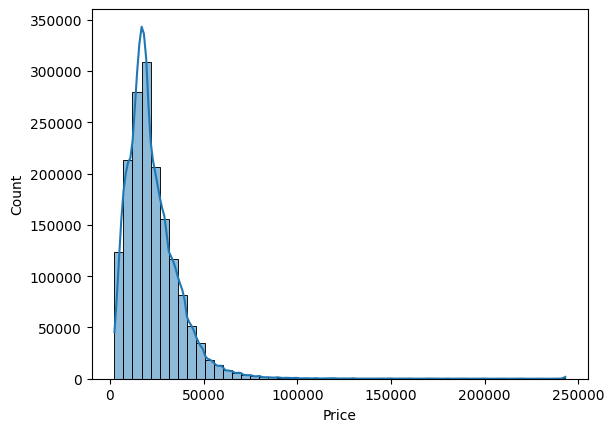

In [21]:
#Distribution of Departure Delays before handling missing values
sns.histplot(vehicles['Price'], bins=50, kde=True)

In [22]:
# A function to identify outliers using IQR
def identify_outliers_iqr(column):
    Q1 = column.quantile(0.25)
    Q3 = column.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = column[(column < lower_bound) | (column > upper_bound)]
    return outliers,lower_bound,upper_bound

In [24]:
# Identify outliers in the 'Price' column
price_outliers,price_lower_bound, price_upper_bound = identify_outliers_iqr(vehicles['Price'])
print(f"Total Number of Price outliers are observed to be {len(price_outliers)} \nwhere upper-bound and lower-bound values are {price_upper_bound},{price_lower_bound} and, \nmaximum and minimum Price values observed in the dataset are {max(vehicles['Price'])} , {min(vehicles['Price'])} respectively!!")


Total Number of Price outliers are observed to be 56213 
where upper-bound and lower-bound values are 52068.5,-9255.5 and, 
maximum and minimum Price values observed in the dataset are 242995.0 , 2495.0 respectively!!


In [25]:
# Winsorization to cap extreme values
vehicles['Price'] = mstats.winsorize(vehicles['Price'], limits=[0.005,0.0005])

# Identify outliers in the 'DEP_DELAY' column
dep_delay_outliers,dep_delay_lower_bound, dep_delay_upper_bound = identify_outliers_iqr(vehicles['Price'])
print(f"Post Winsorization, Total Number of Price outliers are observed to be {len(dep_delay_outliers)} \nwhere upper-bound and lower-bound values are {dep_delay_upper_bound},{dep_delay_lower_bound} and, \nmaximum and minimum Price values observed in the dataset are {max(vehicles['Price'])} , {min(vehicles['Price'])} respectively!!")


Post Winsorization, Total Number of Price outliers are observed to be 56213 
where upper-bound and lower-bound values are 52068.5,-9255.5 and, 
maximum and minimum Price values observed in the dataset are 242995.0 , 2495.0 respectively!!


<Axes: xlabel='Price', ylabel='Count'>

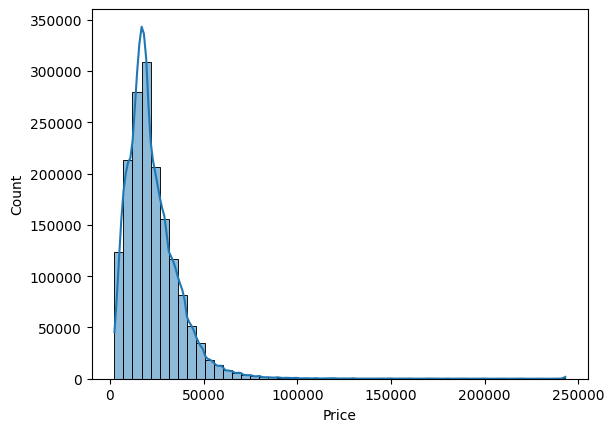

In [26]:
#Distribution of Departure Delays before handling missing values
sns.histplot(vehicles['Price'], bins=50, kde=True)

In [29]:

def most_frequent(col):
  # Filter non-null values
  filtered_col = col.dropna()
  # Return the mode (most frequent value)
  return filtered_col.mode().iloc[0] if not filtered_col.empty else None

# Group data by 'VIN' and aggregate missing values
aggregated_data = vehicles.groupby('Model Name').agg({
  'Manufacturing Year': most_frequent,  # Fill 'year' with the first non-null value
  'Manufacturer': most_frequent,        # Fill 'manufacturer' with the first non-null value
  'cylinders': most_frequent,            # Fill 'cylinders' with the most frequent value
  'drive': most_frequent,                # Fill 'drive' with the most frequent value
  'transmission': most_frequent,          # Fill 'transmission' with the most frequent value
  'State': most_frequent               # Fill 'state' with the first non-null value
})

In [30]:
aggregated_data

,Manufacturing Year,Manufacturer,cylinders,drive,transmission,State
Model Name,,,,,,
"$362.47, $1000 down, oac, 2.9%apr $362.47,luxury low miles $1000 down, only 40k miles",2018,Mercedes-Benz,4 cylinders,rwd,automatic,TX
%,2002,None,6 cylinders,fwd,automatic,AK
(300),2006,Chrysler,8 cylinders,4wd,automatic,NY
*matrix*,2004,Toyota,None,None,automatic,FL
-,2010,Mercedes-Benz,6 cylinders,4wd,automatic,KS
...,...,...,...,...,...,...
zdx,2010,Acura,6 cylinders,4wd,automatic,CO
zephyr,2006,Lincoln,6 cylinders,fwd,automatic,PA
zephyr 4dr sdn,2006,Lincoln,6 cylinders,fwd,automatic,CO


In [34]:
connection = sqlite3.connect('Scraping/UCPP_test.db')

In [35]:
cursor = connection.cursor()

table_name = 'used_cars'
query = f"SELECT * FROM {table_name}"

df = pd.read_sql_query(query, connection)

len(df)

576620

In [36]:
df.columns

Index(['index', 'Unnamed: 0', 'City', 'URL', 'Title', 'Price', 'Tags',
       'Post Content', 'Posting_Attributes', 'Manufacturing Year',
       'Manufacturer', 'Model Name', 'condition', 'cylinders', 'drive', 'fuel',
       'odometer', 'paint color', 'size', 'title status', 'transmission',
       'type', 'VIN', 'Date', 'State', 'State Name', 'City Name'],
      dtype='object')

In [37]:
vehicles.columns

Index(['Unnamed: 0.1', 'Unnamed: 0', 'Price', 'City', 'VIN', 'Date',
       'Manufacturing Year', 'Manufacturer', 'Model Name', 'cylinders',
       'drive', 'transmission', 'odometer', 'Post Content', 'State'],
      dtype='object')

In [38]:
df['Pre_Post_Covid'] = 'Post_Covid'
vehicles['Pre_Post_Covid'] = 'Pre_Covid'

In [40]:

# Assuming df and vehicles are already defined
# Concatenate vertically, ensuring all columns from both DataFrames are preserved
combined_df = pd.concat([df, vehicles], axis=0, ignore_index=True)

# Print or inspect the new combined DataFrame
combined_df.head()


,index,Unnamed: 0,City,URL,Title,Price,Tags,Post Content,Posting_Attributes,Manufacturing Year,...,title status,transmission,type,VIN,Date,State,State Name,City Name,Pre_Post_Covid,Unnamed: 0.1
0,0.0,0.0,abilene,https://abilene.craigslist.org/cto/d/eastland-...,1990 jeep wrangler yj,"$7,800",8h ago·145k mi·Eastland,"1990 jeep wrangler yj, 4.2 liter 6 cylinder, a...","{'Post Content': '1990 jeep wrangler yj, 4.2 l...",1990.0,...,clean,manual,None,None,2024-02-12,TX,None,"Abilene, TX",Post_Covid,NaN
1,1.0,1.0,abilene,https://abilene.craigslist.org/ctd/d/eastland-...,2015 Chevrolet Sonic LT !BUY HERE PAY HERE! Co...,None,2/12·121k mi·Eastland - Valentine's Sweet Savings,Stanley Direct Auto IN HOUSE FINANCE ONLY/NO C...,"{'Post Content': ""Stanley Direct Auto IN HOUSE...",2015.0,...,clean,automatic,sedan,None,2024-02-12,TX,None,"Abilene, TX",Post_Covid,NaN
2,2.0,2.0,abilene,https://abilene.craigslist.org/ctd/d/eastland-...,2014 Hyundai Elantra Sport !BUY HERE PAY HERE!...,None,2/12·104k mi·Eastland - Valentine's Sweet Savings,Stanley Direct Auto IN HOUSE FINANCE ONLY/NO C...,"{'Post Content': ""Stanley Direct Auto IN HOUSE...",2014.0,...,clean,automatic,sedan,None,2024-02-12,TX,None,"Abilene, TX",Post_Covid,NaN
3,3.0,3.0,abilene,https://abilene.craigslist.org/ctd/d/eastland-...,2014 Ford F-150 XLT !BUY HERE PAY HERE! Financ...,None,2/12·113k mi·Eastland - Valentine's Sweet Savings,Stanley Direct Auto IN HOUSE FINANCE ONLY/NO C...,"{'Post Content': ""Stanley Direct Auto IN HOUSE...",2014.0,...,clean,automatic,pickup,None,2024-02-12,TX,None,"Abilene, TX",Post_Covid,NaN
4,4.0,4.0,abilene,https://abilene.craigslist.org/ctd/d/eastland-...,2014 Dodge Avenger SE !BUY HERE PAY HERE! Comp...,None,2/12·112k mi·Eastland - Valentine's Sweet Savings,Stanley Direct Auto IN HOUSE FINANCE ONLY/NO C...,"{'Post Content': ""Stanley Direct Auto IN HOUSE...",2014.0,...,clean,automatic,sedan,None,2024-02-12,TX,None,"Abilene, TX",Post_Covid,NaN


In [41]:
combined_df[combined_df['Pre_Post_Covid'] == 'Pre_Covid'].head()

,index,Unnamed: 0,City,URL,Title,Price,Tags,Post Content,Posting_Attributes,Manufacturing Year,...,title status,transmission,type,VIN,Date,State,State Name,City Name,Pre_Post_Covid,Unnamed: 0.1
576620,NaN,4.0,akron / canton,NaN,NaN,242995.0,NaN,"WE HAVE MOVED TO 2517 FULTON DRIVE NW CANTON, ...",NaN,2019.0,...,NaN,automatic,NaN,00000000000000000,2021-05-04 11:31:57-04:00,OH,NaN,NaN,Pre_Covid,0.0
576621,NaN,144.0,Cleveland,NaN,NaN,159900.0,NaN,We have just added to our extensive exotic car...,NaN,2017.0,...,NaN,A,NaN,00000000020179562,NaN,OH,NaN,NaN,Pre_Covid,1.0
576622,NaN,170.0,orlando,NaN,NaN,2495.0,NaN,Truck is in Great Conditions!!! Clear Title N...,NaN,2012.0,...,NaN,manual,NaN,000000000CD152372,2021-04-29 16:33:48-04:00,FL,NaN,NaN,Pre_Covid,2.0
576623,NaN,171.0,orlando,NaN,NaN,2495.0,NaN,Truck is in Great Condition!!! Clear Title New...,NaN,2012.0,...,NaN,manual,NaN,000000000CD152374,2021-04-29 16:52:33-04:00,FL,NaN,NaN,Pre_Covid,3.0
576624,NaN,199.0,orlando,NaN,NaN,55000.0,NaN,"THIS TRUCKS RUNS, DRIVES AND LOOKS GREAT. TO...",NaN,2003.0,...,NaN,manual,NaN,0000000033D576483,2021-04-28 22:15:37-04:00,FL,NaN,NaN,Pre_Covid,4.0
